Module 10 Case study 1

In [86]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [87]:
data = pd.read_csv('Datasets/additional_resources_10_6qt_ynxafhm/driver-data.csv')
data

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [88]:
# Fields in Data
# • id: Unique Id of the driver 
# • mean_dist_day: Mean distance driven by driver per day
# • mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit

In [89]:
print(data.duplicated().sum())

data.isnull().sum()

0


id                      0
mean_dist_day           0
mean_over_speed_perc    0
dtype: int64

In [90]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [91]:
data.describe()

,id,mean_dist_day,mean_over_speed_perc
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


In [92]:
data['mean_over_speed_perc'].value_counts()

mean_over_speed_perc
5      553
6      524
4      503
7      366
3      353
      ... 
77       1
100      1
83       1
97       1
73       1
Name: count, Length: 96, dtype: int64

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [94]:
scaled_data

array([[-0.44383803, -0.0898104 ,  1.26061251],
       [ 0.66207644, -0.43977285,  1.04174351],
       [ 1.10548146, -0.215131  ,  1.18765617],
       ...,
       [ 0.41006304,  1.77447381,  0.09331115],
       [ 1.02407507,  1.87229869, -0.41738319],
       [-0.79198026,  1.72060465, -0.12555785]], shape=(4000, 3))

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# n_clusters = 4

model = KMeans(n_clusters=4)
model.fit(scaled_data)

predicted_labels = model.predict(scaled_data)

In [96]:
predicted_labels

array([3, 0, 0, ..., 2, 2, 2], shape=(4000,), dtype=int32)

In [97]:

label_counts = pd.DataFrame(predicted_labels)
label_counts.value_counts()

0
0    1514
1    1456
2     694
3     336
Name: count, dtype: int64

In [98]:
model.cluster_centers_

array([[ 0.86626854, -0.48492424, -0.30992439],
       [-0.87436457, -0.48876558, -0.30667007],
       [-0.07711495,  1.95279463, -0.01664897],
       [ 0.04209989,  0.26732861,  2.75069694]])

In [99]:
data['cluster'] = predicted_labels
data['cluster']

0       3
1       0
2       0
3       1
4       1
       ..
3995    2
3996    2
3997    2
3998    2
3999    2
Name: cluster, Length: 4000, dtype: int32

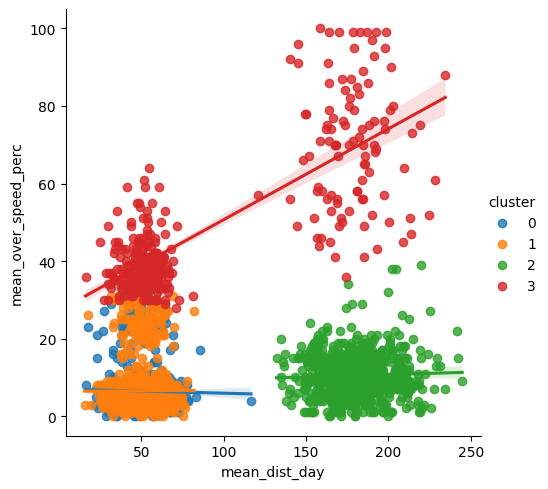

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(data=data, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster')
plt.show()

In [115]:
model.inertia_

3540.2665815283735

In [102]:
from sklearn.metrics import silhouette_score

silhouette_score(data,predicted_labels)

np.float64(0.2214203397047312)

In [103]:
silhouette_score(scaled_data,predicted_labels)

np.float64(0.48185314197519497)

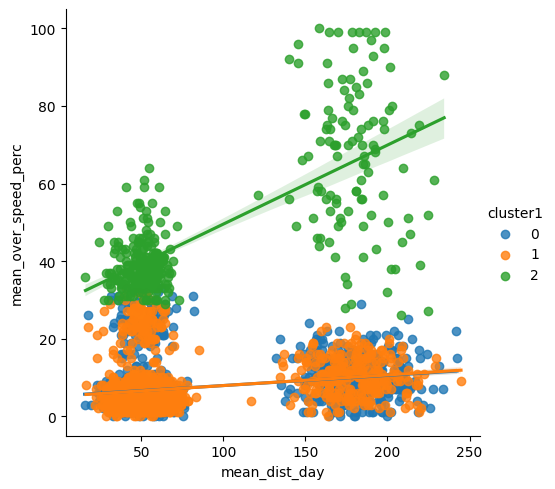

0.37815586504622567


np.float64(0.36746553966256207)

In [104]:
# n_clusters = 3

model1 = KMeans(n_clusters=3)
model1.fit(scaled_data)

predicted_labels1 = model1.predict(scaled_data)

data['cluster1'] = predicted_labels1

sns.lmplot(data=data, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster1')
plt.show()

print(silhouette_score(data,predicted_labels1))
silhouette_score(scaled_data,predicted_labels1)

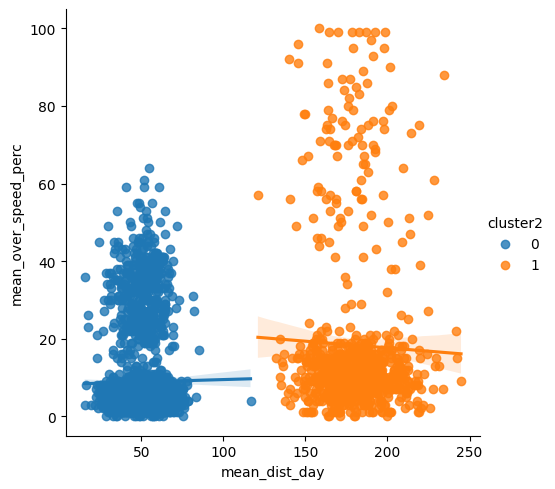

np.float64(0.012139312516694912)

In [105]:
# n_clusters = 2

model2 = KMeans(n_clusters=2)
model2.fit(scaled_data)

predicted_labels2 = model2.predict(scaled_data)

data['cluster2'] = predicted_labels2

sns.lmplot(data=data, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster2')
plt.show()

silhouette_score(data,predicted_labels2)

In [106]:
silhouette_score(scaled_data,predicted_labels2)

np.float64(0.4944336459659611)

In [107]:
model2.cluster_centers_

array([[ 0.01218888, -0.48581565, -0.13816168],
       [-0.0488318 ,  1.94630276,  0.55351131]])

In [108]:
data

,id,mean_dist_day,mean_over_speed_perc,cluster,cluster1,cluster2
0,3423311935,71.24,28,3,0,0
1,3423313212,52.53,25,0,1,0
2,3423313724,64.54,27,0,1,0
3,3423311373,55.69,22,1,0,0
4,3423310999,54.58,25,1,0,0
...,...,...,...,...,...,...
3995,3423310685,160.04,10,2,0,1
3996,3423312600,176.17,5,2,0,1
3997,3423312921,170.91,12,2,1,1
3998,3423313630,176.14,5,2,1,1


In [109]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering()

predicted = agglo.fit_predict(data)

In [110]:
predicted

array([0, 0, 0, ..., 0, 0, 1], shape=(4000,))

In [111]:
agglo.n_clusters_

2

In [112]:
silhouette_score(data, predicted)

np.float64(0.5782010478657458)

In [113]:
print('Kmeans algorithm showcased better results with 2 clusters')

Kmeans algorithm showcased better results with 2 clusters
